In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("Retail Sales Performance Analysis.xlsx")

print("Dataset Shape:", df.shape)
display(df.head())
display(df.info())

Dataset Shape: (50, 13)


,Order_ID,Order_Date,Region,State,Store,Product_Category,Product_Name,Customer_Segment,Sales,Quantity,Discount,Profit,Shipping_Mode
0,R1001,2025-01-05,South,Karnataka,Store D,Electronics,Keyboard,Home Office,51153.0,11,10.0,5115.0,Same Day
1,R1002,2025-01-09,West,Gujarat,Store C,Furniture,Bookshelf,Consumer,33245.0,17,15.0,2493.0,Same Day
2,R1003,2025-01-13,East,Assam,Store B,Furniture,Chair,Consumer,57582.0,3,10.0,5758.0,Standard
3,R1004,2025-01-17,South,Tamil Nadu,Store E,Furniture,Chair,Home Office,50489.0,9,0.0,7573.0,Same Day
4,R1005,2025-01-21,East,Odisha,Store F,Electronics,Speaker,Consumer,48467.0,6,8.0,5331.0,Express


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          50 non-null     object 
 1   Order_Date        50 non-null     object 
 2   Region            50 non-null     object 
 3   State             50 non-null     object 
 4   Store             50 non-null     object 
 5   Product_Category  50 non-null     object 
 6   Product_Name      50 non-null     object 
 7   Customer_Segment  50 non-null     object 
 8   Sales             49 non-null     float64
 9   Quantity          50 non-null     int64  
 10  Discount          49 non-null     float64
 11  Profit            49 non-null     float64
 12  Shipping_Mode     50 non-null     object 
dtypes: float64(3), int64(1), object(9)
memory usage: 5.2+ KB


None

In [2]:
# Missing values
df.isnull().sum()

Order_ID            0
Order_Date          0
Region              0
State               0
Store               0
Product_Category    0
Product_Name        0
Customer_Segment    0
Sales               1
Quantity            0
Discount            1
Profit              1
Shipping_Mode       0
dtype: int64

In [3]:
# Duplicate records
df.duplicated().sum()

np.int64(2)

In [4]:
# Convert date
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_ID          50 non-null     object        
 1   Order_Date        50 non-null     datetime64[ns]
 2   Region            50 non-null     object        
 3   State             50 non-null     object        
 4   Store             50 non-null     object        
 5   Product_Category  50 non-null     object        
 6   Product_Name      50 non-null     object        
 7   Customer_Segment  50 non-null     object        
 8   Sales             49 non-null     float64       
 9   Quantity          50 non-null     int64         
 10  Discount          49 non-null     float64       
 11  Profit            49 non-null     float64       
 12  Shipping_Mode     50 non-null     object        
dtypes: datetime64[ns](1), float64(3), int64(1), object(8)
memory usage: 5.2+ KB


In [7]:
# Display duplicate rows
df[df.duplicated(keep=False)]

,Order_ID,Order_Date,Region,State,Store,Product_Category,Product_Name,Customer_Segment,Sales,Quantity,Discount,Profit,Shipping_Mode
15,R1016,2025-03-06,East,West Bengal,Store A,Electronics,Laptop,Corporate,52919.0,19,10.0,5291.0,Standard
28,R1029,2025-04-27,East,Assam,Store D,Electronics,Monitor,Corporate,18454.0,15,12.0,1660.0,Same Day
48,R1016,2025-03-06,East,West Bengal,Store A,Electronics,Laptop,Corporate,52919.0,19,10.0,5291.0,Standard
49,R1029,2025-04-27,East,Assam,Store D,Electronics,Monitor,Corporate,18454.0,15,12.0,1660.0,Same Day


In [8]:
df = df.drop_duplicates()

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.describe()

,Order_Date,Sales,Quantity,Discount,Profit
count,48,47.000000,48.000000,47.000000,47.000000
mean,2025-04-09 00:00:00,41500.893617,9.562500,7.085106,4717.234043
min,2025-01-05 00:00:00,2041.000000,1.000000,0.000000,306.000000
25%,2025-02-21 00:00:00,24328.000000,5.000000,2.000000,2573.500000
50%,2025-04-09 00:00:00,48369.000000,8.000000,8.000000,4961.000000
75%,2025-05-26 00:00:00,58086.000000,15.250000,10.000000,6773.000000
max,2025-07-12 00:00:00,69637.000000,20.000000,15.000000,9664.000000
std,NaN,20439.959410,5.760859,5.007949,2516.369972


In [11]:
print("Total Sales:", df["Sales"].sum())
print("Total Profit:", df["Profit"].sum())
print("Total Quantity:", df["Quantity"].sum())

Total Sales: 1950542.0
Total Profit: 221710.0
Total Quantity: 459


In [12]:
df.groupby("Product_Category")["Sales"].sum()

Product_Category
Electronics        559823.0
Furniture          635782.0
Office Supplies    754937.0
Name: Sales, dtype: float64

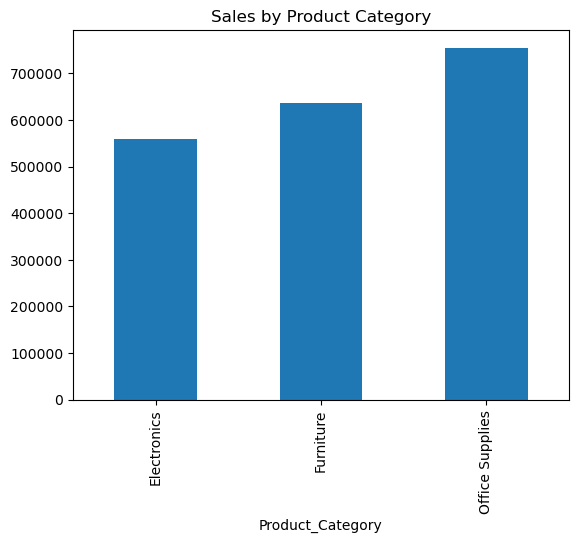

In [13]:
df.groupby("Product_Category")["Sales"].sum().plot(kind="bar")
plt.title("Sales by Product Category")
plt.show()

In [14]:
df.groupby("Product_Category")["Profit"].sum()

Product_Category
Electronics        57737.0
Furniture          72505.0
Office Supplies    91468.0
Name: Profit, dtype: float64

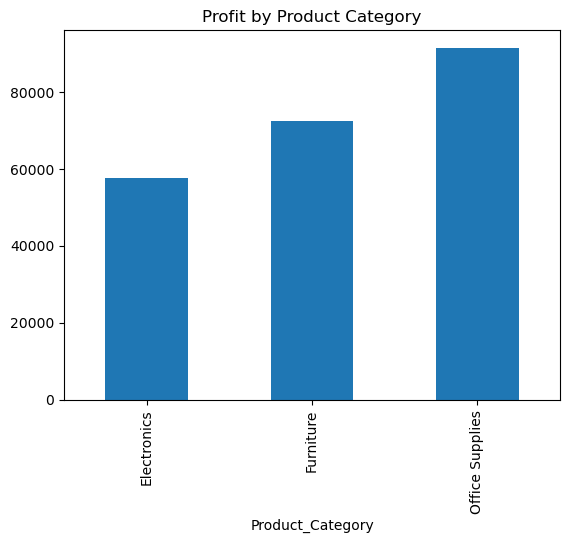

In [15]:
df.groupby("Product_Category")["Profit"].sum().plot(kind="bar")
plt.title("Profit by Product Category")
plt.show()

In [16]:
df.groupby("Region")["Sales"].sum()

Region
East     419263.0
North    334981.0
South    504167.0
West     692131.0
Name: Sales, dtype: float64

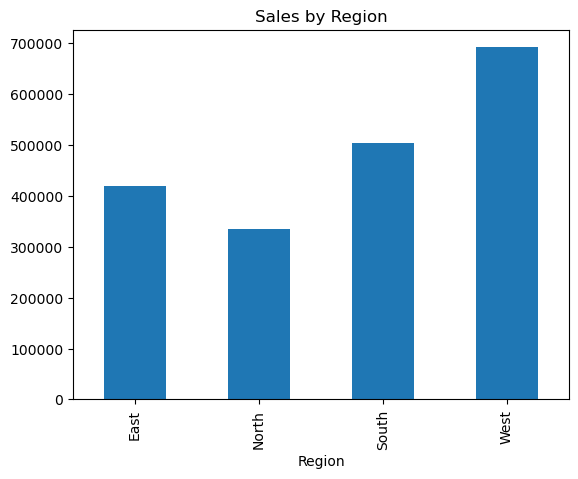

In [17]:
df.groupby("Region")["Sales"].sum().plot(kind="bar")
plt.title("Sales by Region")
plt.show()

In [18]:
df.groupby("Customer_Segment")["Sales"].sum()

Customer_Segment
Consumer       919106.0
Corporate      567298.0
Home Office    464138.0
Name: Sales, dtype: float64

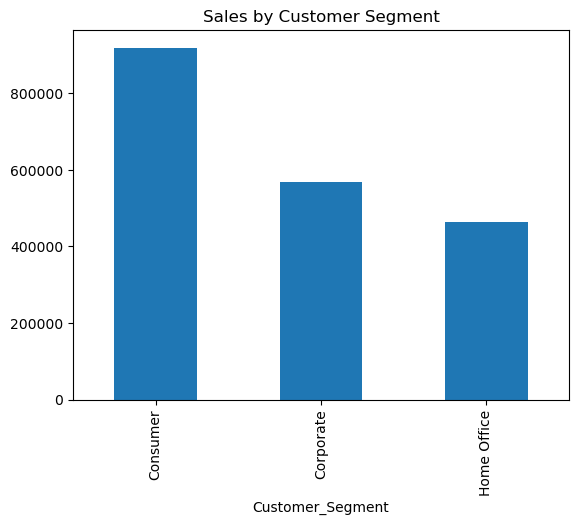

In [19]:
df.groupby("Customer_Segment")["Sales"].sum().plot(kind="bar")
plt.title("Sales by Customer Segment")
plt.show()

In [20]:
df.groupby("Product_Name")["Sales"].sum().sort_values(ascending=False).head(10)

Product_Name
Markers      186995.0
Speaker      181754.0
Keyboard     170341.0
Pen Set      166202.0
Cabinet      152538.0
Paper        150865.0
Table        143055.0
Files        134543.0
Bookshelf    132157.0
Chair        128147.0
Name: Sales, dtype: float64

In [21]:
df["Month"] = df["Order_Date"].dt.month

df.groupby("Month")["Sales"].sum()

Month
1    333551.0
2    239605.0
3    273266.0
4    203619.0
5    421487.0
6    303878.0
7    175136.0
Name: Sales, dtype: float64

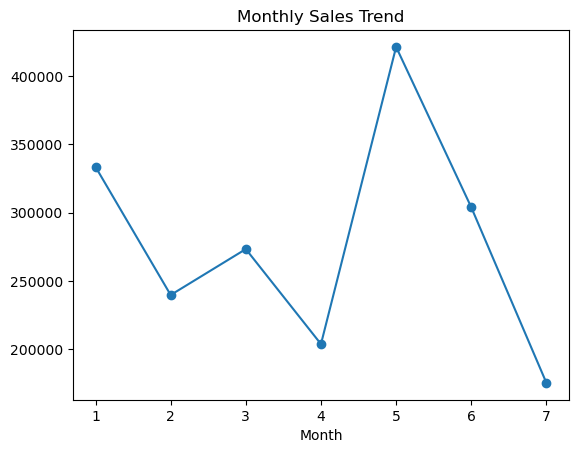

In [22]:
df.groupby("Month")["Sales"].sum().plot(kind="line", marker="o")
plt.title("Monthly Sales Trend")
plt.show()

In [23]:
df.groupby("Month")["Profit"].sum()

Month
1    36099.0
2    33986.0
3    27887.0
4    17507.0
5    50847.0
6    37147.0
7    18237.0
Name: Profit, dtype: float64

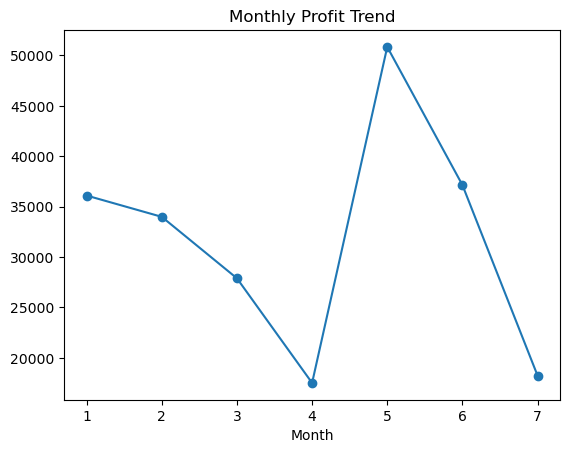

In [24]:
df.groupby("Month")["Profit"].sum().plot(kind="line", marker="o")
plt.title("Monthly Profit Trend")
plt.show()

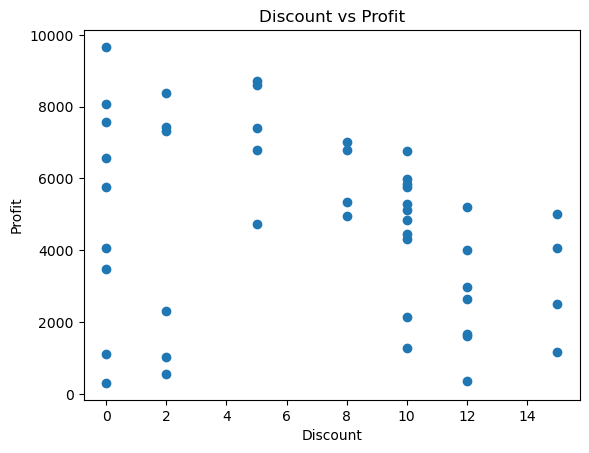

In [25]:
plt.scatter(df["Discount"], df["Profit"])
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.title("Discount vs Profit")
plt.show()

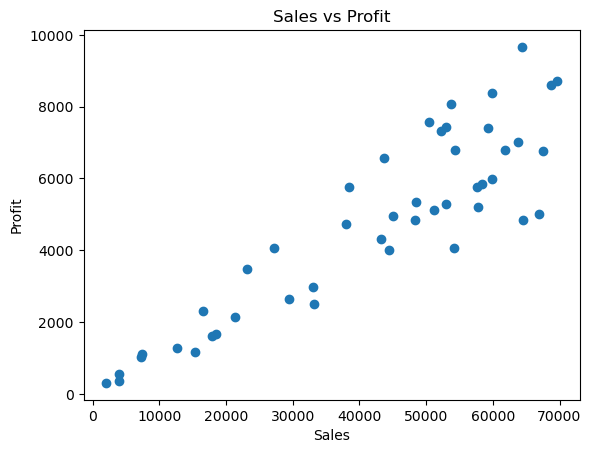

In [26]:
plt.scatter(df["Sales"], df["Profit"])
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.title("Sales vs Profit")
plt.show()

In [27]:
df[["Sales", "Profit", "Quantity", "Discount"]].corr()

,Sales,Profit,Quantity,Discount
Sales,1.000000,0.898404,0.077746,0.073094
Profit,0.898404,1.000000,0.107768,-0.285549
Quantity,0.077746,0.107768,1.000000,-0.121718
Discount,0.073094,-0.285549,-0.121718,1.000000


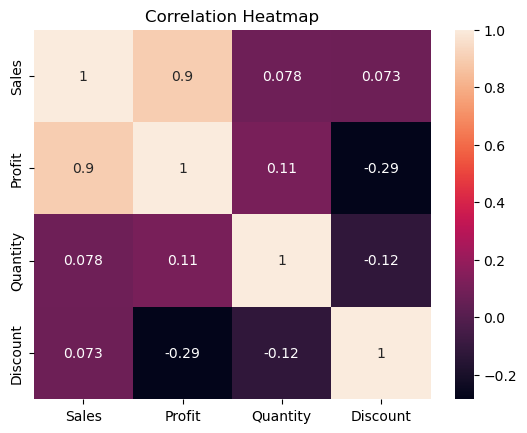

In [28]:
sns.heatmap(df[["Sales", "Profit", "Quantity", "Discount"]].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

## Key Findings

- Office Supplies generated the highest sales and profit among all product categories.
- The West region recorded the highest sales and profit.
- Consumer customers contributed the highest sales among all customer segments.
- Store H generated the highest sales, while Store G recorded the lowest sales.
- May was the strongest month in terms of sales and profit.
- Sales and profit showed a strong positive relationship.
- Higher discounts showed a negative relationship with profit.
- Quantity showed only a weak relationship with sales.

## Business Insights

- Office Supplies is an important revenue and profit contributor, making it a key category for business growth.
- The West region is the strongest-performing region and can be studied to identify practices that can be applied to other regions.
- The Consumer segment contributes the largest share of sales, indicating its importance to overall business revenue.
- Store performance varies considerably, suggesting that lower-performing stores should be examined for factors such as product mix, sales volume, and profitability.
- May recorded the highest sales and profit during the available period, indicating a strong business period that can be studied for seasonal or operational factors.
- The strong positive relationship between sales and profit indicates that higher sales are generally associated with higher profit in this dataset.
- The negative relationship between discount and profit suggests that increasing discounts may reduce profitability and should therefore be monitored carefully.

## Business Recommendations

- Maintain strong focus on the Office Supplies category while identifying opportunities to improve the performance of other categories.
- Study the sales and operational practices of the West region and apply relevant practices to lower-performing regions.
- Develop strategies to retain and increase purchases from the Consumer customer segment.
- Review the performance of lower-sales stores and identify opportunities related to product mix, customer demand, and sales strategy.
- Analyze the factors behind the strong performance in May and consider using similar strategies during weaker periods.
- Monitor discount levels carefully because higher discounts may negatively affect profit.
- Focus on profitable sales growth rather than increasing sales through excessive discounting.